In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

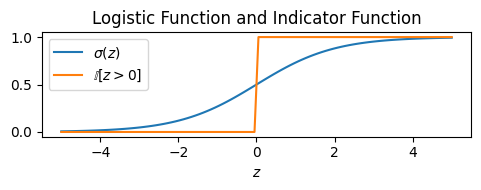

In [2]:
z = np.linspace(-5.0, 5.0, 100)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(5.0, 2.0))
ax.plot(z, sigma, label=r"$\sigma(z)$")
ax.plot(z, z > 0.0, label=r"$\mathbb{I}[z > 0]$")
ax.set(
    xlabel="$z$",
    title="Logistic Function and Indicator Function",
)
ax.legend(loc="best")
fig.tight_layout()
fig.savefig("../figures/logistic_function.svg", transparent=True)

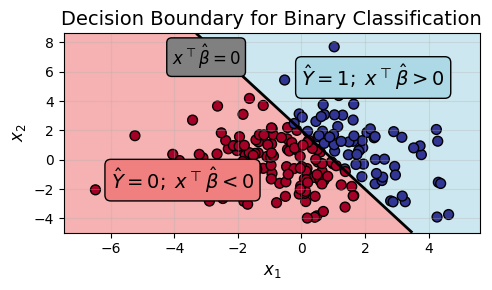

In [3]:
# Generate toy classification data
np.random.seed(42)
n_samples = 200

# Generate random 2D points
X = np.random.randn(n_samples, 2) * 2

# Create a linear decision boundary: x1 + 0.5*x2 - 1 = 0
# This gives us the line: x2 = -2*x1 + 2
y = (X[:, 0] + 0.5 * X[:, 1] - 1) > 0

# Create a grid for plotting the decision boundary
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1), np.arange(x2_min, x2_max, 0.1))

# Calculate decision boundary values for the grid
Z = (xx1 + 0.5 * xx2 - 1) > 0

# Create the plot
fig, ax = plt.subplots(figsize=(5, 3))

# Plot the decision boundary regions
contour = ax.contourf(xx1, xx2, Z, levels=1, colors=['lightcoral', 'lightblue'], alpha=0.6)

# Plot the decision boundary line
ax.contour(xx1, xx2, xx1 + 0.5 * xx2 - 1, levels=[0], colors='black', linewidths=2)

# Plot the data points
scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=50)

# Add labels for the regions
ax.text(0, 5, r'$\hat{Y} = 1; \; x^\top \hat\beta > 0$', fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue'))
ax.text(-6, -2, r'$\hat{Y} = 0; \; x^\top \hat\beta < 0$', fontsize=14, bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral'))
ax.text(-3, 7, r'$x^\top \hat\beta = 0$', fontsize=12, color='black', ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor='gray'))

# Set labels and title
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.set_title('Decision Boundary for Binary Classification', fontsize=14)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/decision_boundary.svg", transparent=True)